In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from pathlib import Path
from matplotlib.dates import YearLocator, DateFormatter

results_output_path = Path('../results/domestic_international_travel_data_exploration/')
results_output_path.joinpath('figures').mkdir(parents=True, exist_ok=True)

In [2]:
html_tables = pd.read_html('https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FMF&QO_fu146_anzr=Nv4%20Pn44vr45')
columns_discription_table = html_tables[4].iloc[:, :2]
new_header = columns_discription_table.iloc[0] 
columns_discription_table = columns_discription_table[2:] 
columns_discription_table.columns = new_header
columns_discription_table = columns_discription_table.reset_index(drop=True)

In [3]:
columns_discription_table

,Field Name,Description
0,Passengers,On-Flight Market Passengers Enplaned
1,Freight,On-Flight Market Freight Enplaned (pounds)
2,Mail,On-Flight Market Mail Enplaned (pounds)
3,Distance,Distance between airports (miles)
4,Carrier,Carrier
5,UniqueCarrier,Unique Carrier Code. When the same code has be...
6,AirlineID,An identification number assigned by US DOT to...
7,UniqueCarrierName,Unique Carrier Name. When the same name has be...
8,UniqCarrierEntity,Unique Entity for a Carrier's Operation Region.
9,CarrierRegion,Carrier's Operation Region. Carriers Report Da...


In [4]:
data_file = Path('../data/T100_domestic/processed/final_enriched_t100_data.parquet')
df = pd.read_parquet(data_file)

In [5]:
df

,PASSENGERS,FREIGHT,MAIL,DISTANCE,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,...,origin_trade_pct_gdp,dest_inflation_cp,dest_gdp,dest_gdp_per_capita,dest_population,dest_tourism_arrivals,dest_trade_pct_gdp,U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon),Travel_type,Travel_type_continent
0,0,0,0,0,HP,19991,America West Airlines Inc.,06049,D,HP,...,15.270116,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.494,Domestic,Domestic
1,0,0,0,0,HP,19991,America West Airlines Inc.,06049,D,HP,...,15.270116,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.971,Domestic,Domestic
2,0,0,0,0,HP,19991,America West Airlines Inc.,06049,D,HP,...,15.270116,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.535,Domestic,Domestic
3,0,0,0,0,HP,19991,America West Airlines Inc.,06049,D,HP,...,15.270116,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.791,Domestic,Domestic
4,0,0,0,0,HP,19991,America West Airlines Inc.,06049,D,HP,...,15.270116,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.494,Domestic,Domestic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10179062,83663,87134,210,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.094,Domestic,Domestic
10179063,84275,562218,5,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.069,Domestic,Domestic
10179064,84832,204449,0,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.069,Domestic,Domestic
10179065,86078,58485,0,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.928,Domestic,Domestic


In [6]:
pd.DataFrame({'Count of Nulls': df.isna().sum(),'Dtype': df.dtypes})

,Count of Nulls,Dtype
PASSENGERS,0,Int64
FREIGHT,0,Int64
MAIL,0,Int64
DISTANCE,0,Int64
UNIQUE_CARRIER,0,category
...,...,...
dest_tourism_arrivals,211748,float64
dest_trade_pct_gdp,294213,float64
U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon),54574,float64
Travel_type,0,object


In [7]:
df.loc[df.YEAR == 2019].groupby('Travel_type')['PASSENGERS'].sum()

Travel_type
Domestic                  813713752
Inbound International     121430954
Outbound International    120852494
Name: PASSENGERS, dtype: Int64

These numbers are pretty close to official numbers, assuming that when it says "to and from the US" it means 115 million each way, not their total

U.S. airlines passengers in 2019
- Systemwide:  927 million, up 4.2% from 2018 (889M)
- Domestic: 811 million, up 4.3% from 2018 (778M)
- International* (to and from the U.S.): 115 million, up 3.8% from 2018 (111M)

https://www.bts.gov/newsroom/final-full-year-2019-traffic-data-us-airlines-and-foreign-airlines

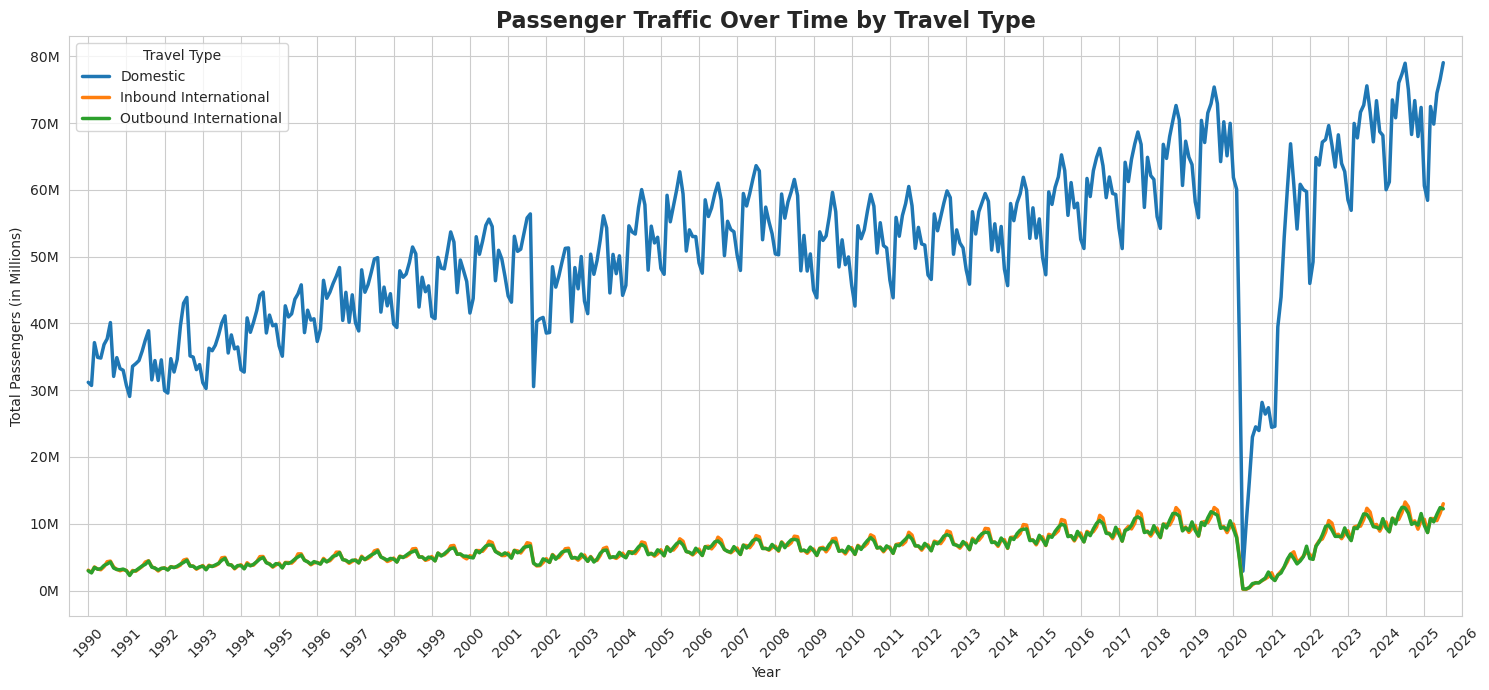

In [8]:
plot_df = df.groupby(['date', 'Travel_type'], as_index=False)['PASSENGERS'].sum()

sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

p = sns.lineplot(
    data=plot_df,
    x='date', 
    y='PASSENGERS',
    hue='Travel_type',
    linewidth=2.5
)

# Format the Y-Axis (Millions)
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.0f}M')
p.yaxis.set_major_formatter(formatter)
min_date = plot_df['date'].min() - pd.DateOffset(months=6)
max_date = plot_df['date'].max() + pd.DateOffset(months=6)
p.set_xlim(min_date, max_date)
p.xaxis.set_major_locator(YearLocator(1))
p.xaxis.set_major_formatter(DateFormatter('%Y'))

p.set_title('Passenger Traffic Over Time by Travel Type', fontsize=16, fontweight='bold')
p.set_xlabel('Year')
p.set_ylabel('Total Passengers (in Millions)')
plt.legend(title='Travel Type', loc='upper left')
plt.xticks(rotation=45, ha='center')
plt.tight_layout()
fig = p.get_figure()
fig.savefig(results_output_path / "figures" / "all_passenger_travel_type_timeseries.png", dpi=300)

### Figure Conclusions
- Covid pandemic had a huge impact on domestic and international travel
- Domestic travel recovered quicker after the pandemic than international
- Domestic travel may still not have recovered to where it would be had covid not happened
- 9/11 appears to have had a larger impact on domestic travel than international
- Peak in domestic travel in 2007/2008 followed by a period of reduced travel until 2014/2015
- Large spike in summer domestic travel in 1992
- Domestic seasonality: less travel in fall, more travel in summer

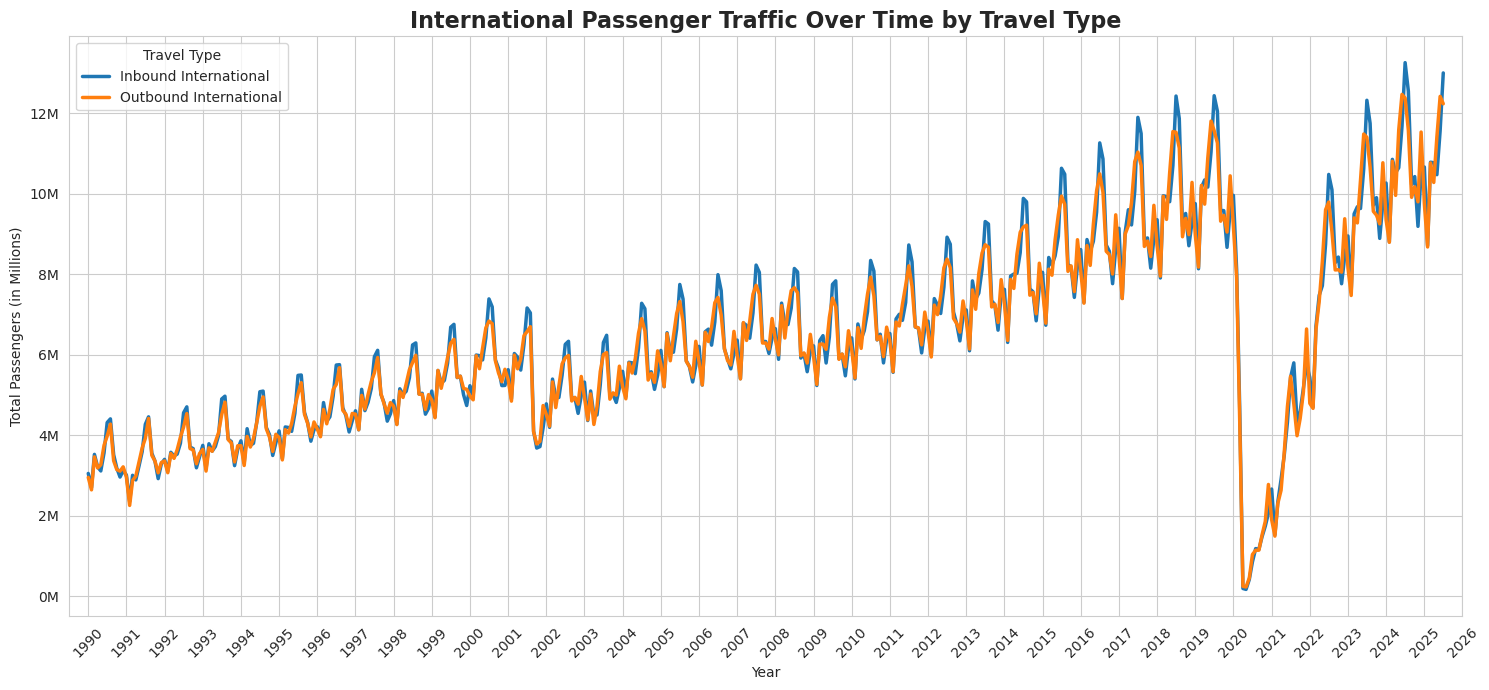

In [9]:
plot_df = df.loc[df.Travel_type.isin(['Inbound International', 'Outbound International'])]
plot_df = plot_df.groupby(['date', 'Travel_type'], as_index=False)['PASSENGERS'].sum()

sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

p = sns.lineplot(
    data=plot_df,
    x='date', 
    y='PASSENGERS',
    hue='Travel_type',
    linewidth=2.5
)

# Format the Y-Axis (Millions)
formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.0f}M')
p.yaxis.set_major_formatter(formatter)
min_date = plot_df['date'].min() - pd.DateOffset(months=6)
max_date = plot_df['date'].max() + pd.DateOffset(months=6)
p.set_xlim(min_date, max_date)
p.xaxis.set_major_locator(YearLocator(1))
p.xaxis.set_major_formatter(DateFormatter('%Y'))

p.set_title('International Passenger Traffic Over Time by Travel Type', fontsize=16, fontweight='bold')
p.set_xlabel('Year')
p.set_ylabel('Total Passengers (in Millions)')
plt.legend(title='Travel Type', loc='upper left')
plt.xticks(rotation=45, ha='center')
plt.tight_layout()
fig = p.get_figure()
fig.savefig(results_output_path / "figures" / "international_passenger_travel_type_timeseries.png", dpi=300)

### Figure Conclusions
- Larger inbound passengers than outbound during summer months, with smaller surpluses/deficits in other months
- 9/11 impact is apparent, hard to tell if more/less than its effect on domestic travel due to differences in seasonality
- Seasonality: peak in summer whereas rest of year is more even

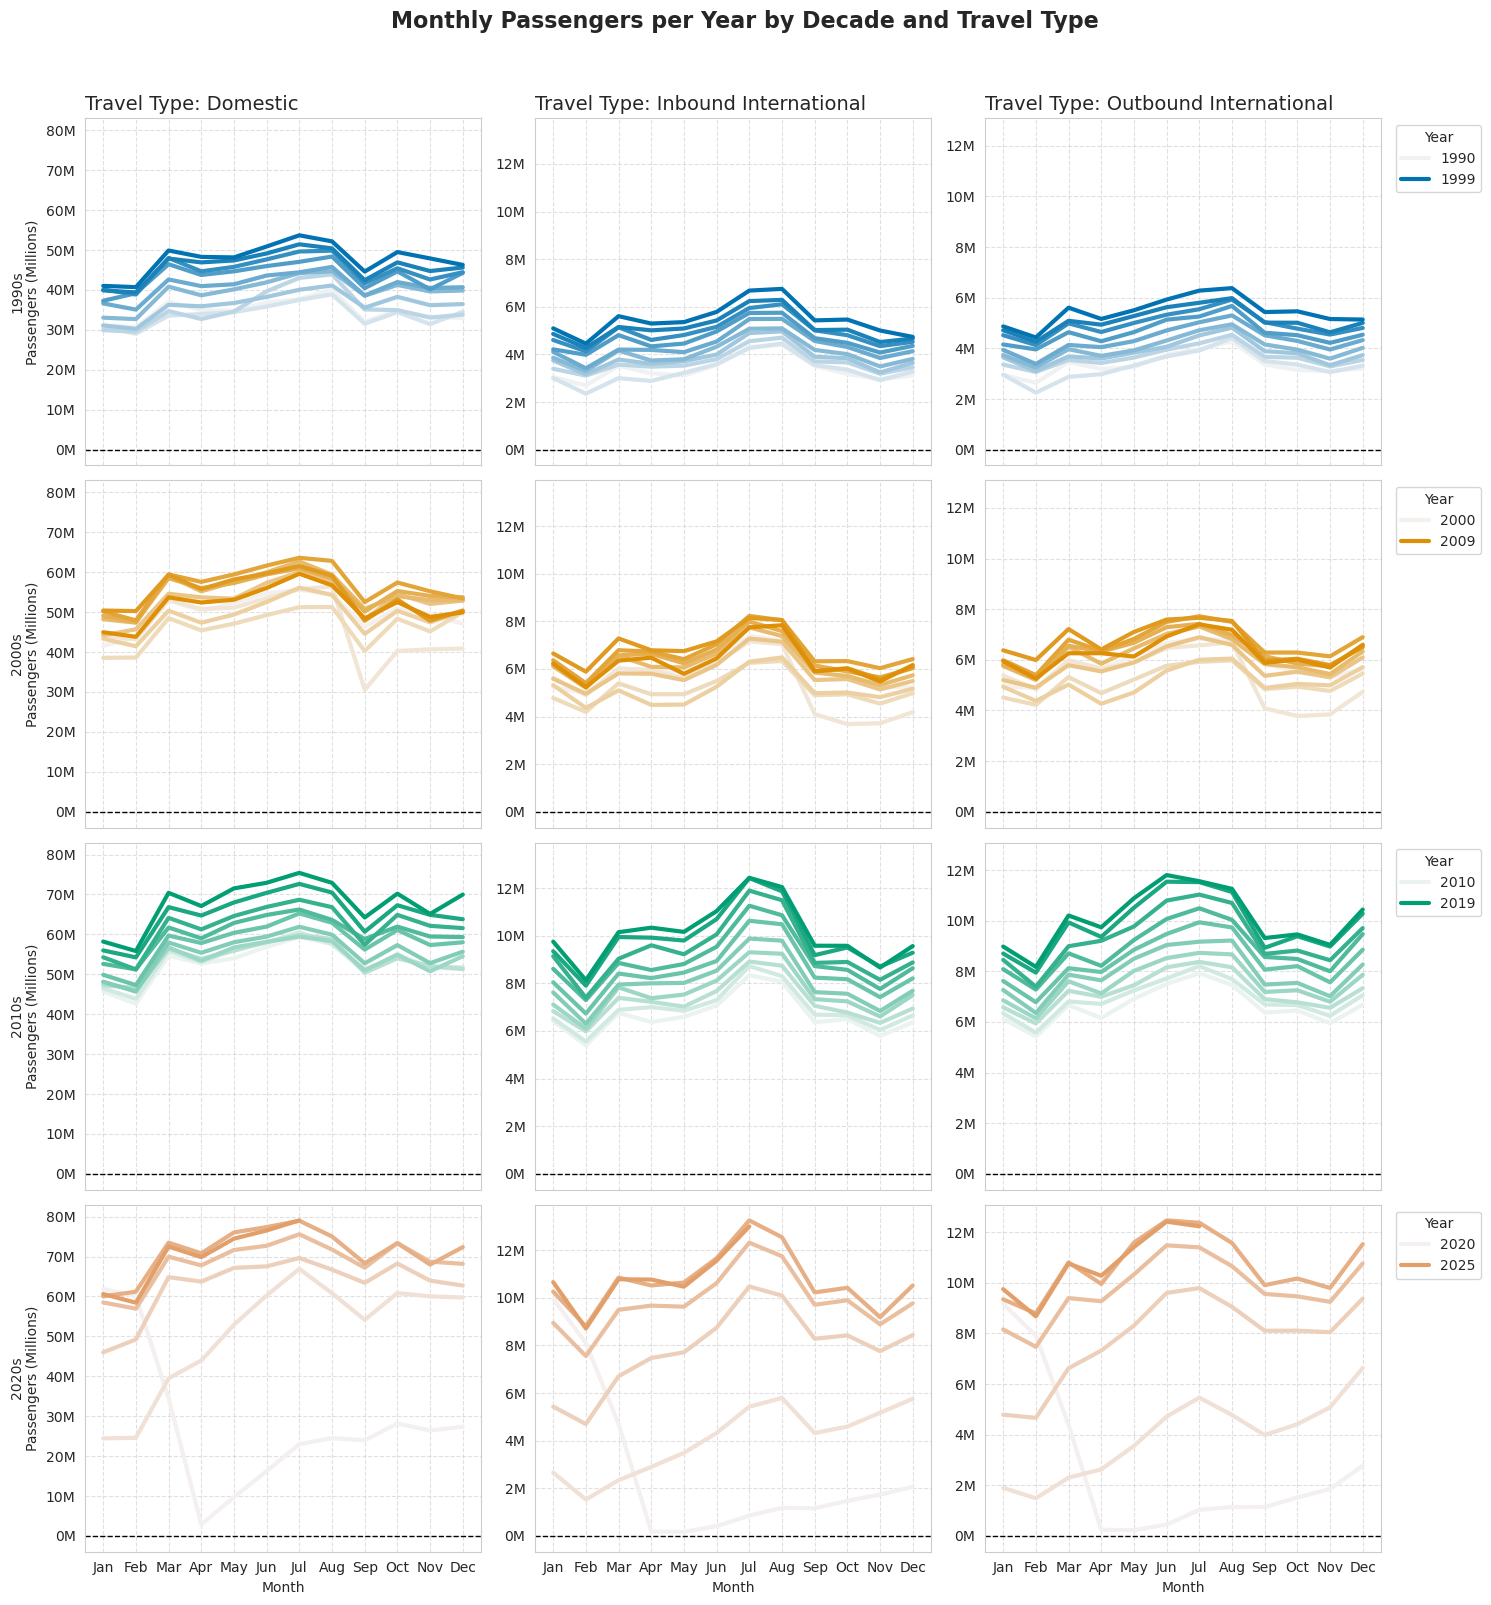

In [10]:
plot_df = df.groupby(['YEAR', 'MONTH', 'Travel_type'], as_index=False)['PASSENGERS'].sum()
month_labels = [pd.to_datetime(str(m), format='%m').strftime('%b') for m in range(1, 13)]

plot_df['decade'] = (plot_df['YEAR'] // 10) * 10
travel_types = sorted(plot_df['Travel_type'].unique())
num_travel_types = len(travel_types)
decades = sorted(plot_df['decade'].unique())
num_decades = len(decades)

# --- 3. Create the Plot ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(
    num_decades, 
    num_travel_types, 
    figsize=(15, 4 * num_decades), 
    sharex=True,
    sharey='col'
)
fig.suptitle('Monthly Passengers per Year by Decade and Travel Type', fontsize=16, fontweight='bold', y=1)

base_colors = sns.color_palette("colorblind", num_decades)


for i, decade in enumerate(decades):
    for j, travel_type in enumerate(travel_types):
        
        ax = axes[i, j]
            
        travel_type_data = plot_df[
            (plot_df['decade'] == decade) & (plot_df['Travel_type'] == travel_type)
        ]

        # Define the color palette for this specific subplot
        years_in_travel_type = sorted(travel_type_data['YEAR'].unique())
        n_colors = max(10, len(years_in_travel_type))
        custom_palette_list = sns.light_palette(base_colors[i], n_colors=n_colors)
        color_map = dict(zip(years_in_travel_type, custom_palette_list))

        sns.lineplot(
            data=travel_type_data,
            x='MONTH',
            y='PASSENGERS',
            hue='YEAR',
            palette=color_map,
            ax=ax,
            legend=True,
            linewidth=3
        )

        # --- Format titles and labels ---
        if i == 0:
            ax.set_title(f"Travel Type: {travel_type}", loc='left', fontsize=14)
        if j == 0:
            ax.set_ylabel(f"{decade}s\nPassengers (Millions)")
        else:
            ax.set_ylabel(None)
            
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
        
        formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.0f}M')
        ax.yaxis.set_major_formatter(formatter)
        
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_labels)
        ax.set_xlabel('Month')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        handles, labels = ax.get_legend_handles_labels()
        
        # Check if this is the LAST subplot in the row
        if j == num_travel_types - 1:
            filtered_handles = [handles[0], handles[-1]]
            filtered_labels = [labels[0], labels[-1]]

            ax.get_legend().remove()
            ax.legend(
                handles=filtered_handles, 
                labels=filtered_labels, 
                title='Year',
                bbox_to_anchor=(1.02, 1), 
                loc='upper left'
            )
        else:
            ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(results_output_path / 'figures' / 'Monthly_passengers_per_year_by_decade_and_travel_type.png', dpi=300)

### Figure Conclusion
- Year-over-year, passenger numbers increase for almost every year and month
- Seasonality hasn't change much
- Seasonality for domesitc is more even, with Jan and Feb having lowest numbers, and all other months close tofether with the peaks in June and July
- Seasonality for International is more pronounced, with Feb bing lowest and summer being highest
- Outbound international has a rounder summer peak compared to inbound international
    - Likely due to international students going back to home countries for summer
- Huge drop in March and April 2020. Domestic recoverd much faster

In [11]:
plot_df = df.copy()
plot_df['Continent'] = plot_df['Travel_type_continent'].str.split(r' from | to ').str[-1]
plot_df.loc[plot_df['Travel_type_continent'] == 'Domestic', 'Continent'] = 'Domestic'

In [12]:
plot_df = plot_df.groupby(['date', 'Continent'])['PASSENGERS'].sum().reset_index()

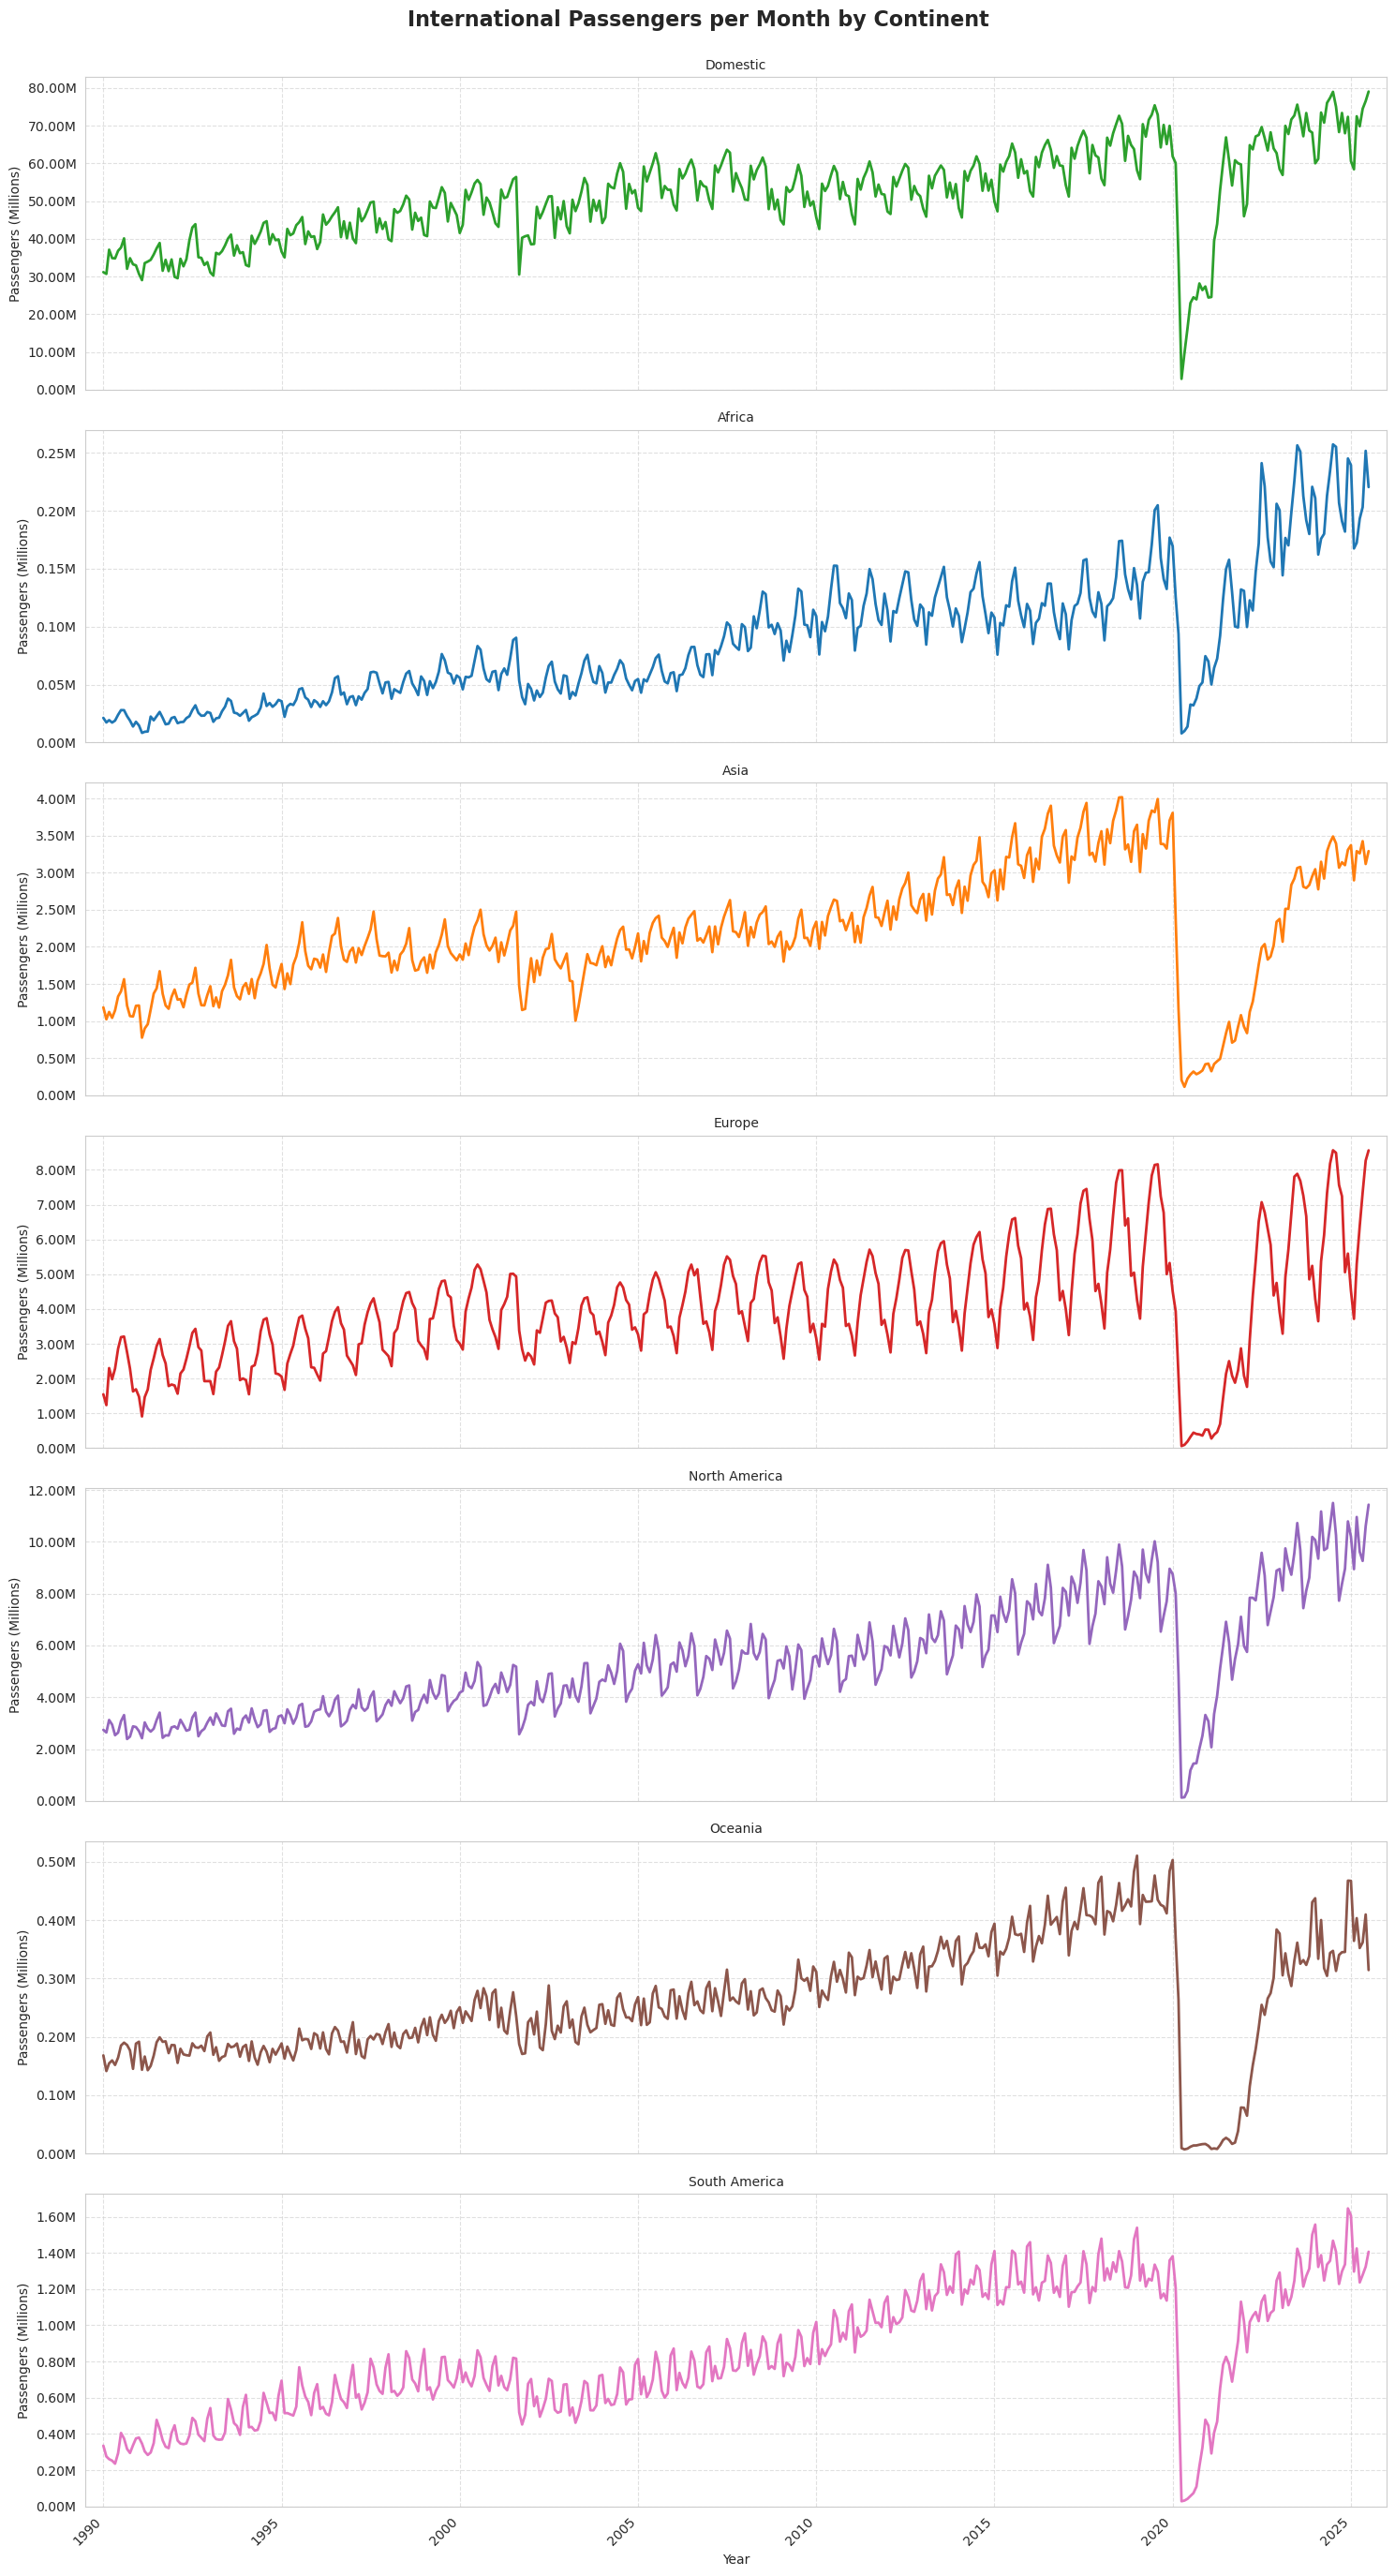

In [13]:
row_order = sorted(plot_df['Continent'].unique(), key=lambda x: x != 'Domestic')

g = sns.relplot(
    data=plot_df,
    x='date',
    y='PASSENGERS',
    hue='Continent',
    row='Continent',
    row_order=row_order,
    kind='line',
    legend=False,
    facet_kws={'sharey': False},
    linewidth=2,
    height=4,
    aspect=3.75)

formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.2f}M')

for ax in g.axes.flat:

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.yaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax.set_ylim(0, ax.get_ylim()[1])
    ax.set_xlim(
        df['date'].min() - pd.DateOffset(months=6), 
        df['date'].max() + pd.DateOffset(months=6)
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

g.set_axis_labels("Year", "Passengers (Millions)")
g.set_titles("{row_name}", fontsize=16)
g.fig.suptitle('International Passengers per Month by Continent', fontsize=16, fontweight='bold', y=0.98)
g.despine(top=False, right=False)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(results_output_path / 'figures' / 'total_passengers_per_month_continent_breakdown.png', dpi=300)

In [14]:
from prophet import Prophet
import logging

# Get the logger for Prophet's backend
logger = logging.getLogger('cmdstanpy')
# Set its logging level to WARNING (or ERROR)
logger.setLevel(logging.WARNING)

import matplotlib.lines as mlines

/home/natti/miniforge3/envs/airtravel/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


17:59:24 - cmdstanpy - INFO - Chain [1] start processing
17:59:25 - cmdstanpy - INFO - Chain [1] done processing
17:59:25 - cmdstanpy - INFO - Chain [1] start processing
17:59:25 - cmdstanpy - INFO - Chain [1] done processing
17:59:25 - cmdstanpy - INFO - Chain [1] start processing
17:59:25 - cmdstanpy - INFO - Chain [1] done processing
17:59:25 - cmdstanpy - INFO - Chain [1] start processing
17:59:25 - cmdstanpy - INFO - Chain [1] done processing
17:59:25 - cmdstanpy - INFO - Chain [1] start processing
17:59:25 - cmdstanpy - INFO - Chain [1] done processing
17:59:26 - cmdstanpy - INFO - Chain [1] start processing
17:59:26 - cmdstanpy - INFO - Chain [1] done processing
17:59:26 - cmdstanpy - INFO - Chain [1] start processing
17:59:26 - cmdstanpy - INFO - Chain [1] done processing


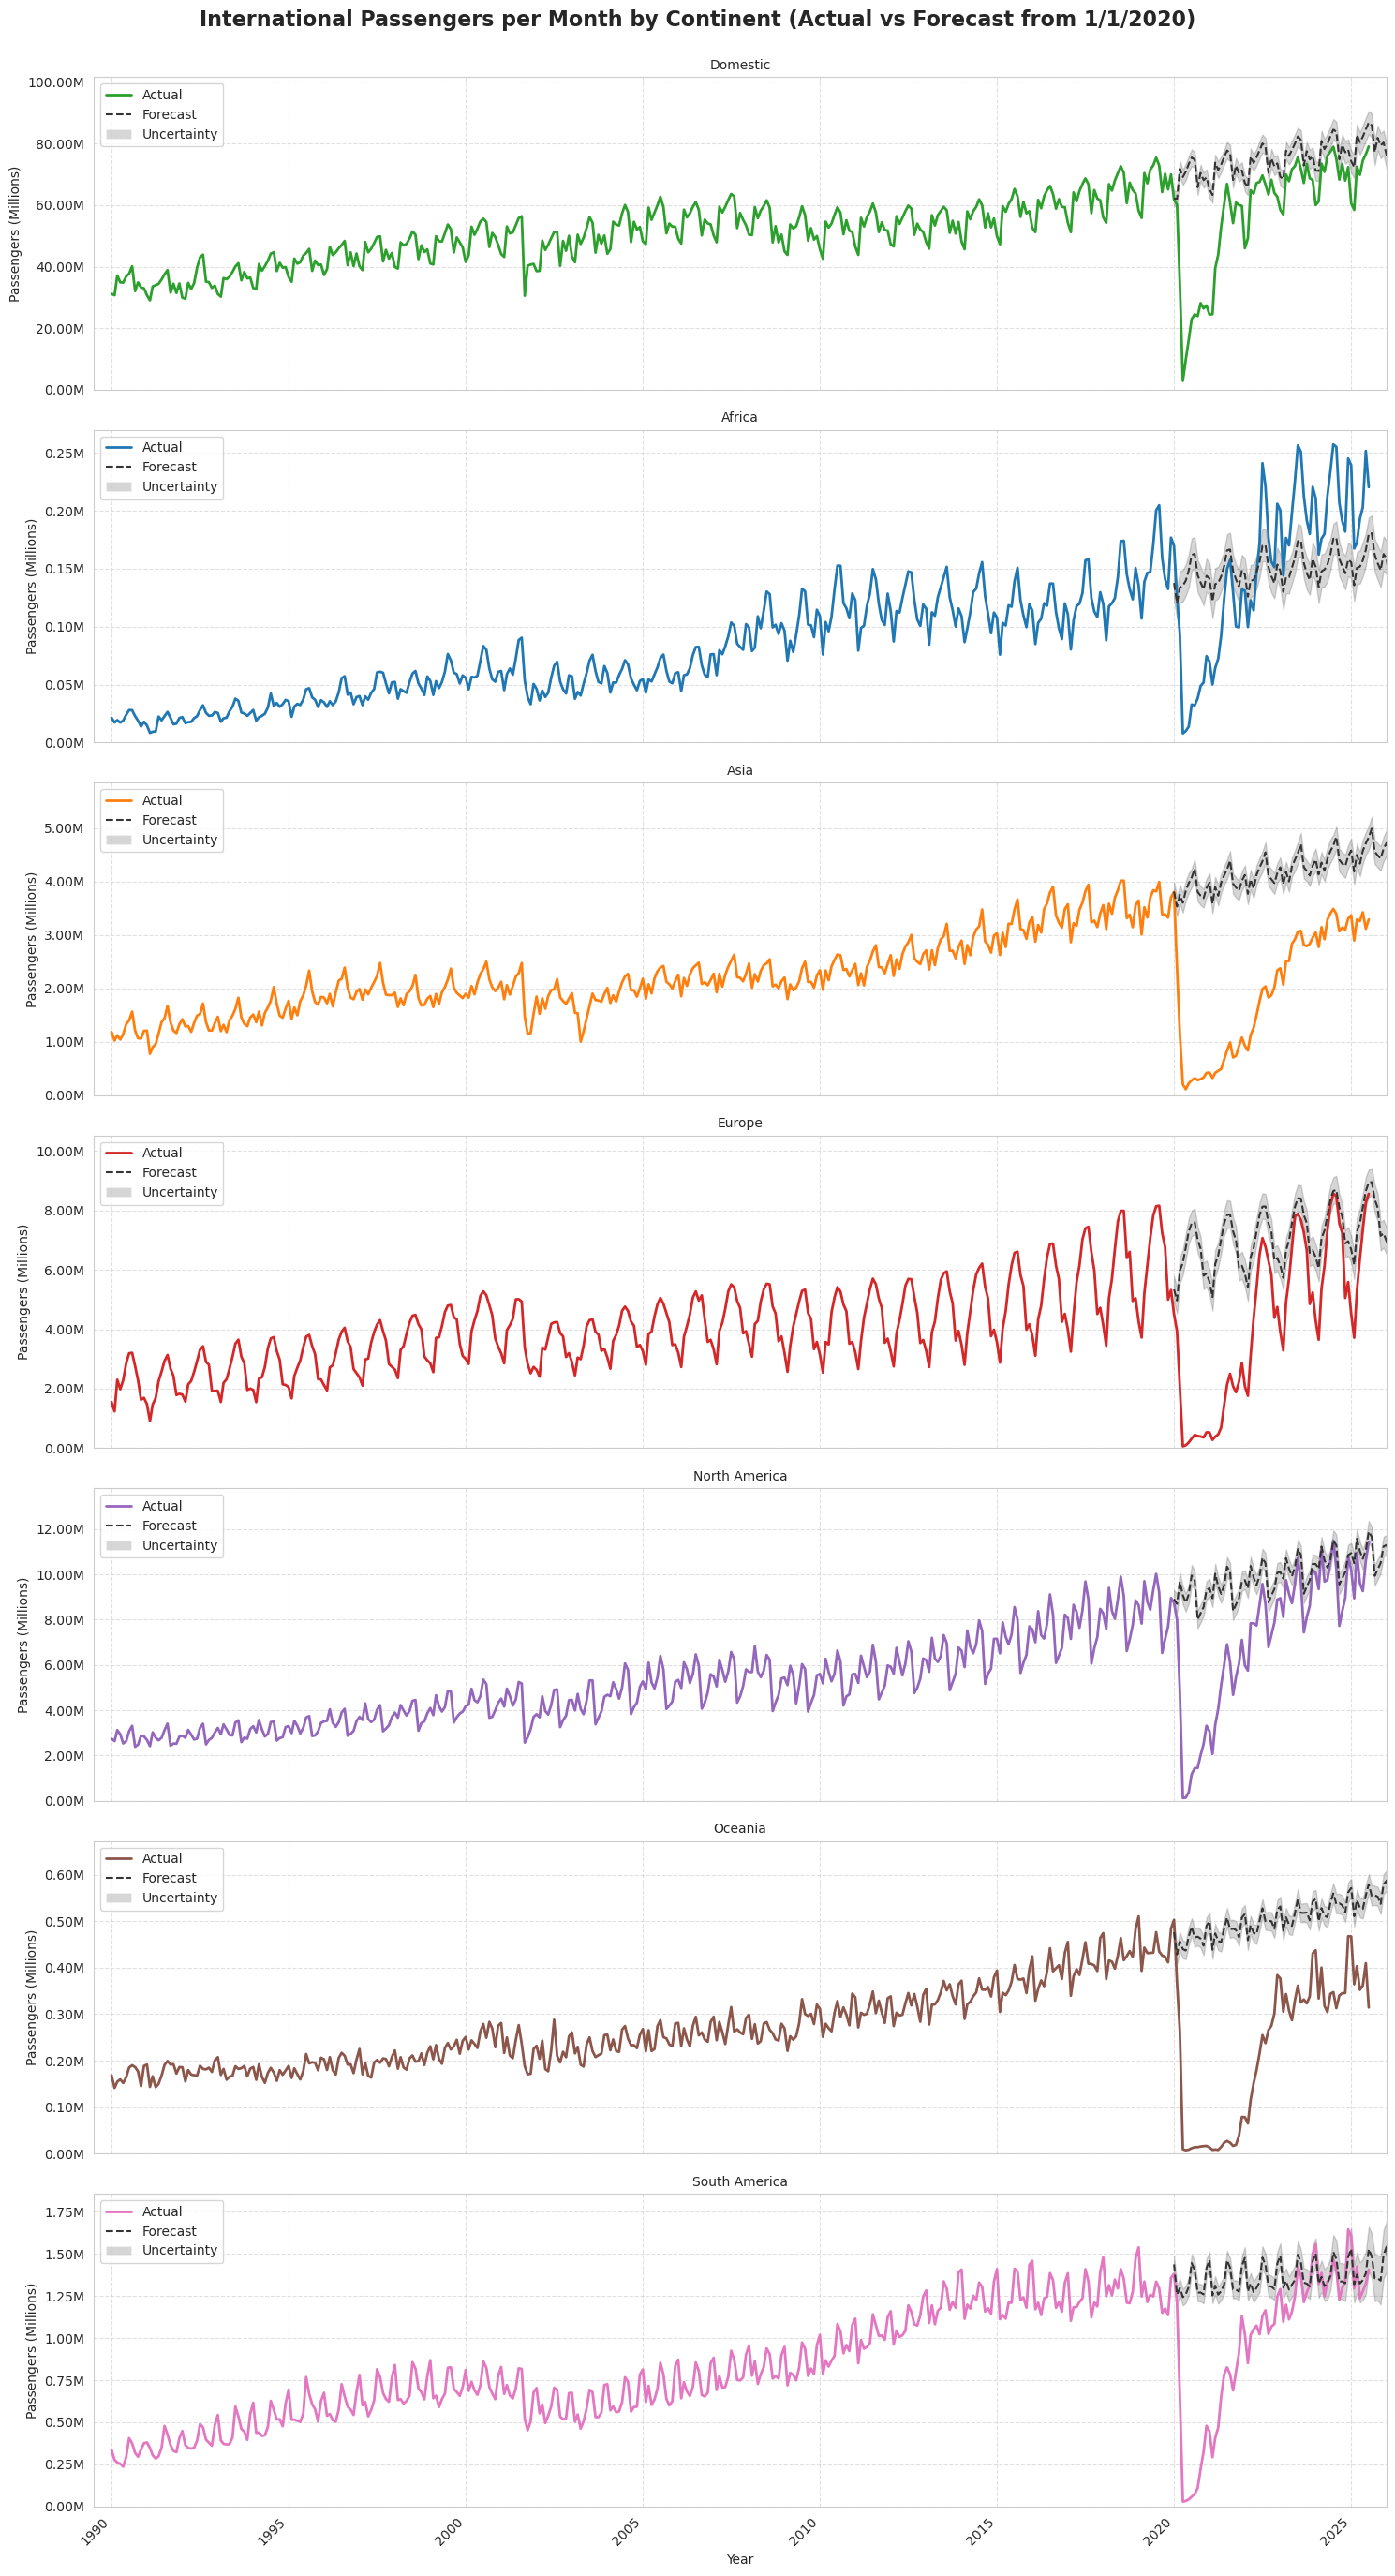

In [15]:
forecast_color = '#333333'

row_order = sorted(plot_df['Continent'].unique(), key=lambda x: x != 'Domestic')

g = sns.relplot(
    data=plot_df,
    x='date',
    y='PASSENGERS',
    hue='Continent',
    row='Continent',
    row_order=row_order,
    kind='line',
    legend=False,
    facet_kws={'sharey': False},
    linewidth=2,
    height=4,
    aspect=3.75)

formatter = FuncFormatter(lambda y, pos: f'{y / 1_000_000:.2f}M')

for i, ax in enumerate(g.axes.flat):
    continent = row_order[i]
    
    continent_data = plot_df[plot_df['Continent'] == continent]
    prophet_df = continent_data[['date', 'PASSENGERS']].rename(columns={'date': 'ds', 'PASSENGERS': 'y'})
    train_df = prophet_df[prophet_df['ds'] < '2020-01-01']

    if len(train_df) > 24: # Prophet needs at least 2 years

        model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False).fit(train_df)
        future_df = model.make_future_dataframe(periods=8*12, freq='MS')
        forecast = model.predict(future_df)
        forecast_to_plot = forecast[forecast['ds'] >= '2020-01-01']

        ax.plot(forecast_to_plot['ds'], forecast_to_plot['yhat'], color=forecast_color, linestyle='--', linewidth=1.5, label='Forecast')
        ax.fill_between(forecast_to_plot['ds'], forecast_to_plot['yhat_lower'], forecast_to_plot['yhat_upper'], color=forecast_color, alpha=0.2)

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.yaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax.set_ylim(0, ax.get_ylim()[1])
    ax.set_xlim(
        df['date'].min() - pd.DateOffset(months=6), 
        df['date'].max() + pd.DateOffset(months=6)
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    actual_line = ax.get_lines()[0]
    actual_color = actual_line.get_color()
    actual_line.set_label('Actual')

    actual_proxy = mlines.Line2D([], [], color=actual_color, linewidth=2, label='Actual')
    forecast_proxy = mlines.Line2D([], [], color=forecast_color, linestyle='--', linewidth=1.5, label='Forecast')
    uncertainty_proxy = plt.Rectangle((0, 0), 1, 1, fc=forecast_color, alpha=0.2, label='Uncertainty')

    ax.legend(handles=[actual_proxy, forecast_proxy, uncertainty_proxy], loc='upper left')

g.set_axis_labels("Year", "Passengers (Millions)")
g.set_titles("{row_name}", fontsize=16)
g.fig.suptitle('International Passengers per Month by Continent (Actual vs Forecast from 1/1/2020)', fontsize=16, fontweight='bold', y=0.98)
g.despine(top=False, right=False)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(results_output_path / 'figures' / 'total_passengers_per_month_continent_breakdown_with_forecast.png', dpi=300)

# Stopped here

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure data_dte is datetime
df['data_dte'] = pd.to_datetime(df['data_dte'])
df['month'] = df['data_dte'].dt.month
df['year'] = df['data_dte'].dt.year

# Filter out rows with missing destination country or passengers
df_filtered = df.dropna(subset=['dest_country_name', 'PASSENGERS'])

# --- 2. Group by Country and Month ---
print("--- Aggregating passenger data by country and month ---")
country_monthly = df_filtered.groupby(['dest_country_name', 'year', 'month'])['PASSENGERS'].sum().reset_index()
country_monthly['data_dte'] = pd.to_datetime(country_monthly[['year', 'month']].assign(DAY=1))

# --- 3. Feature Engineering ---
print("--- Engineering features for clustering ---")
features = []
for country, group in country_monthly.groupby('dest_country_name'):
    pre_covid = group[(group['year'] >= 2015) & (group['year'] <= 2019)]
    post_covid = group[group['year'] == 2023]
    baseline_2019 = group[group['year'] == 2019]

    if pre_covid.empty or baseline_2019.empty or post_covid.empty:
        continue

    # Feature 1: Pre-Covid Seasonality
    summer_avg = pre_covid[pre_covid['month'].isin([6, 7, 8])]['PASSENGERS'].mean()
    winter_avg = pre_covid[pre_covid['month'].isin([1, 2, 12])]['PASSENGERS'].mean()

    # --- CORRECTED LINE ---
    # Check for NA *before* comparing to zero
    if pd.isna(winter_avg) or winter_avg <= 0:
        seasonality_ratio = 1.0  # Assign default if winter avg is missing or zero
    else:
        seasonality_ratio = summer_avg / winter_avg
    # --- END CORRECTION ---
        
    # Feature 2: Recovery Ratio
    total_2023 = post_covid['PASSENGERS'].sum()
    total_2019 = baseline_2019['PASSENGERS'].sum()
    recovery_ratio = total_2023 / total_2019 if total_2019 > 0 else 0.0
    
    features.append({
        'country': country,
        'seasonality_ratio': seasonality_ratio,
        'recovery_ratio': recovery_ratio
    })

if not features:
    print("Error: No countries found with sufficient data for feature engineering.")
else:
    df_features = pd.DataFrame(features).set_index('country')
    # Handle potential infinities or NaNs from ratios
    df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_features.dropna(inplace=True)

    # --- 4. Clustering ---
    print("--- Performing K-Means Clustering ---")
    if len(df_features) < 4:
        print("Not enough countries to perform meaningful clustering.")
    else:
        # Scale the features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(df_features)

        # Apply K-Means (let's try 4 clusters)
        kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
        df_features['cluster'] = kmeans.fit_predict(scaled_features)

        # --- 5. Analyze Results ---
        print("\n--- Cluster Centers (Scaled Features) ---")
        centers_df = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df_features.columns[:-1])
        print(centers_df)
        
        print("\n--- Countries per Cluster ---")
        print(df_features['cluster'].value_counts())

        print("\n--- Example Countries per Cluster ---")
        for i in range(4):
            print(f"\nCluster {i}:")
            print(df_features[df_features['cluster'] == i].head(5).index.tolist())
            
        # Optional: Save the cluster assignments
        #df_features.to_csv("results/country_clusters.csv")
        #print("\nCluster assignments saved to results/country_clusters.csv")

--- Aggregating passenger data by country and month ---
--- Engineering features for clustering ---
--- Performing K-Means Clustering ---

--- Cluster Centers (Scaled Features) ---
   seasonality_ratio  recovery_ratio
0           1.337571        1.348566
1           1.000000       11.000000
2         315.349451        0.309930
3           1.377441        0.371534

--- Countries per Cluster ---
cluster
0    79
3    55
2     1
1     1
Name: count, dtype: int64

--- Example Countries per Cluster ---

Cluster 0:
['Anguilla', 'Antigua and Barbuda', 'Aruba', 'Bahamas', 'Belgium']

Cluster 1:
['Jersey']

Cluster 2:
['Czech Republic']

Cluster 3:
['American Samoa', 'Angola', 'Argentina', 'Australia', 'Austria']



--- Visualizing Clusters ---


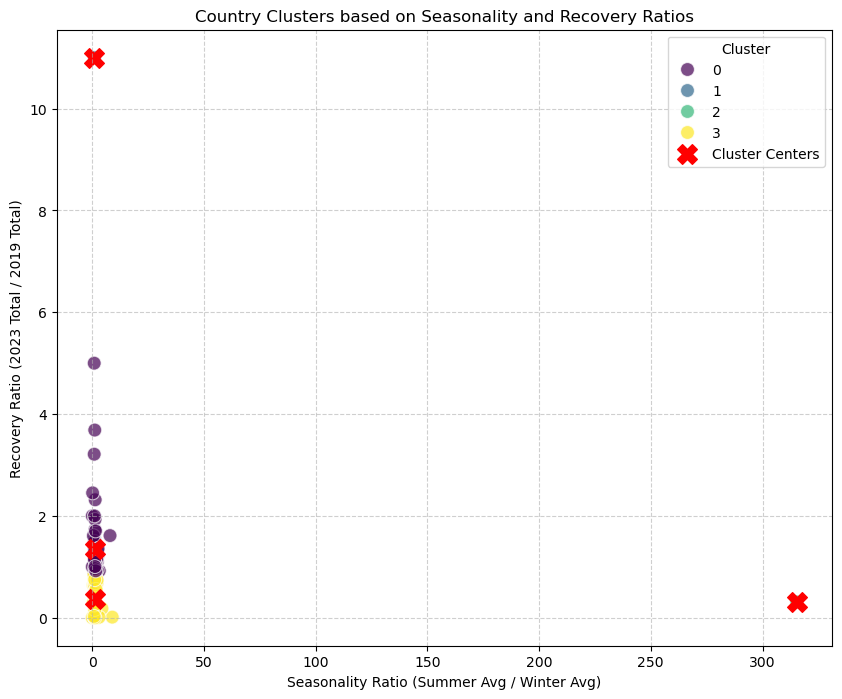

In [10]:
# (Keep the code before this the same: load data, engineer features, scale, cluster)
# Assume 'df_features' now has the 'cluster' column

print("\n--- Visualizing Clusters ---")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_features,
    x='seasonality_ratio',
    y='recovery_ratio',
    hue='cluster', # Color points by cluster assignment
    palette='viridis', # Use a distinct color palette
    s=100, # Make points larger
    alpha=0.7
)

# Add cluster centers to the plot (using unscaled values)
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers_unscaled[:, 0], centers_unscaled[:, 1],
    marker='X', s=200, c='red', label='Cluster Centers'
)

plt.title('Country Clusters based on Seasonality and Recovery Ratios')
plt.xlabel('Seasonality Ratio (Summer Avg / Winter Avg)')
plt.ylabel('Recovery Ratio (2023 Total / 2019 Total)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Save the plot
# plt.savefig("results/country_cluster_scatter.png")
# plt.close()


--- Performing PCA ---
Explained Variance Ratio by Component: [0.52877911 0.47122089]


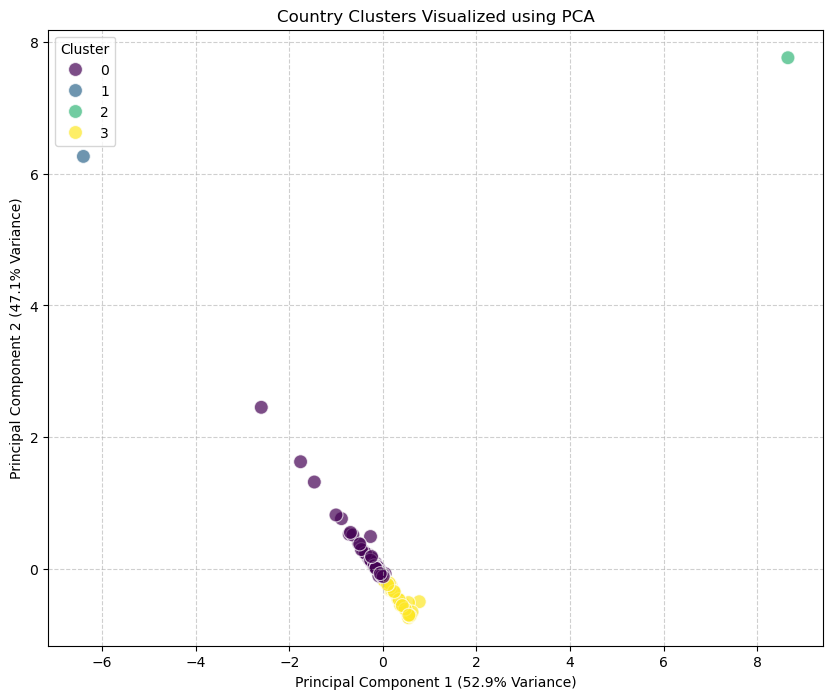

In [11]:
from sklearn.decomposition import PCA

# --- Perform PCA on the SCALED features ---
print("\n--- Performing PCA ---")
pca = PCA(n_components=2) # We want to keep both components
pca.fit(scaled_features)

# Print explained variance ratio
print(f"Explained Variance Ratio by Component: {pca.explained_variance_ratio_}")

# Create a DataFrame with the PCA results
df_pca = pd.DataFrame(
    pca.transform(scaled_features),
    columns=['PC1', 'PC2'],
    index=df_features.index
)
df_pca['cluster'] = df_features['cluster'] # Add cluster labels

# --- Visualize PCA Results ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Country Clusters Visualized using PCA')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Save the plot
# plt.savefig("results/country_cluster_pca.png")
# plt.close()